# Part 1, MZI design

We start by importing all the libraries, we will use

In [1]:
import numpy as np
import gdsfactory as gf

gf.gpdk.PDK.activate()

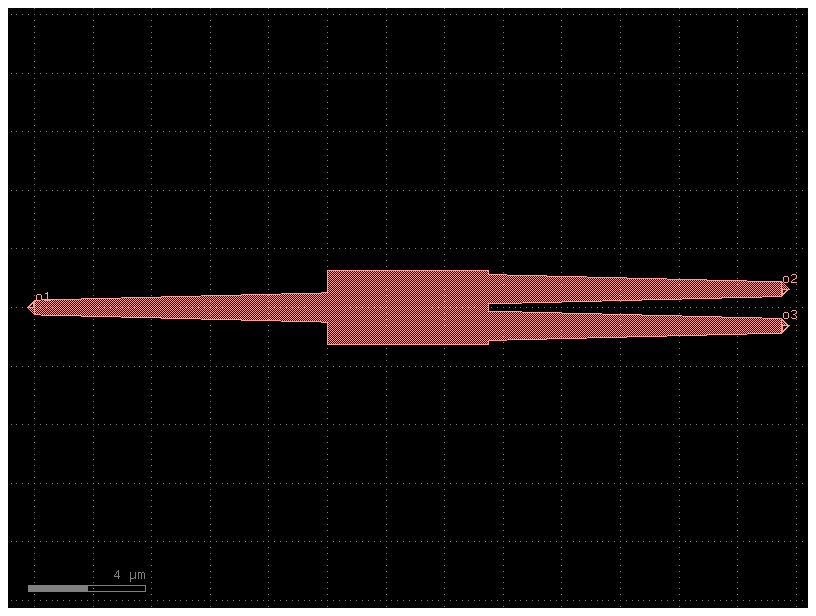

In [2]:
c = gf.components.mmi1x2(width_taper=1, length_taper=10, length_mmi=5.5, width_mmi=2.5, gap_mmi=0.25, cross_section='strip').copy()
c.draw_ports()
c.plot()
c.show()

# //////  FIN DE LA FUNCIÓN MZI#### Start defining the MZI function.

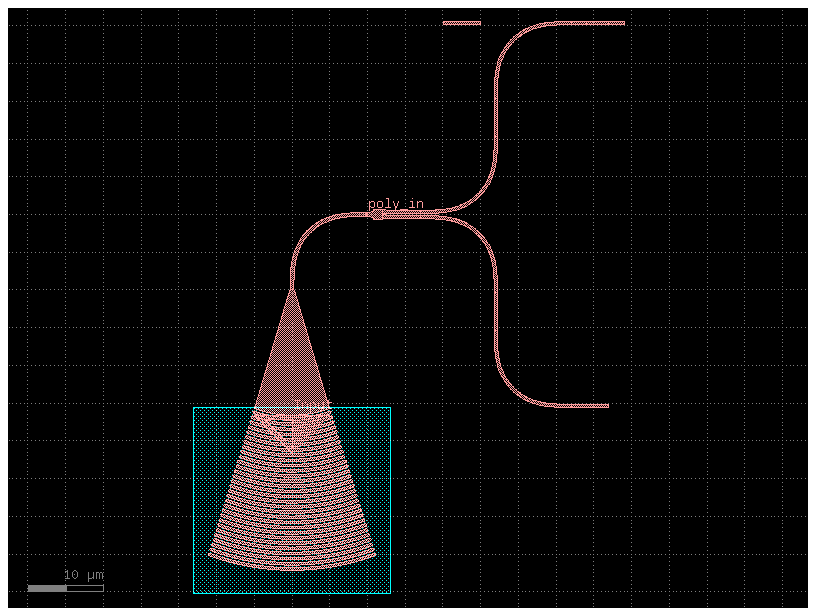

In [42]:

# def Y_splitter (dir = "in",
#                 widths = [0.5, 0.5, 0.6, 0.7, 0.9,1.26, 1.4, 1.4, 1.4, 1.4,1.31, 1.2, 1.2],
#                 splitter_len = 2.0,
#                 layer = (1,0),
#                 taper_length = 5.0,
#                 taper_width_in = 0.5,
#                 taper_width_out = 0.42, ):
#
#     c = gf.Component()
#
#     if dir == "in":
#
#         n = len(widths)
#         dx = splitter_len / n
#
#         # x positions
#         xs = np.linspace(0, splitter_len, n)
#
#         # Upper and lower boundaries
#         y_top = np.array(widths) / 2
#         y_bot = -y_top
#
#         # Build central polygon
#         points = []
#
#         # top boundary (left → right)
#         for x, y in zip(xs, y_top):
#             points.append((x, y))
#
#         # bottom boundary (right → left)
#         for x, y in zip(xs[::-1], y_bot[::-1]):
#             points.append((x, y))
#
#         c.add_polygon(points, layer=layer)
#
#         # --- Split into two arms at the end ---
#         split_gap = widths[-1] - taper_width_in
#
#         # Upper arm
#         upper_taper = gf.components.taper(
#             length=taper_length,
#             width1=taper_width_in,
#             width2=taper_width_out,
#             layer=layer,
#         )
#         t1 = c.add_ref(upper_taper)
#         t1.move((taper_length, split_gap / 2))
#
#         # Lower arm
#         lower_taper = gf.components.taper(
#             length=taper_length,
#             width1=taper_width_in,
#             width2=taper_width_out,
#             layer=layer,
#         )
#         t2 = c.add_ref(lower_taper)
#         t2.move((taper_length, -split_gap / 2))
#
#         c.add_port(
#             name="poly_in",
#             center=(0, 0),
#             width=taper_width_in,
#             orientation=180,
#             layer=layer,
#         )
#     elif dir == "out":
#         n = len(widths)
#         dx = splitter_len / n
#
#         # x positions
#         xs = np.linspace(-splitter_len,0, n)
#
#         # Upper and lower boundaries
#         y_top = np.array(widths) / 2
#         y_bot = -y_top
#
#         # Build central polygon
#         points = []
#
#         # top boundary (left → right)
#         for x, y in zip(xs, y_top):
#             points.append((x, y))
#
#         # bottom boundary (right → left)
#         for x, y in zip(xs[::-1], y_bot[::-1]):
#             points.append((x, y))
#
#         c.add_polygon(points, layer=layer)
#
#         # --- Split into two arms at the end ---
#         split_gap = widths[-1] - taper_width_in
#
#         # Upper arm
#         upper_taper = gf.components.taper(
#             length=taper_length,
#             width1=taper_width_in,
#             width2=taper_width_out,
#             layer=layer,
#         )
#         t1 = c.add_ref(upper_taper)
#         t1.move((taper_length, split_gap / 2))
#
#         # Lower arm
#         lower_taper = gf.components.taper(
#             length=taper_length,
#             width1=taper_width_in,
#             width2=taper_width_out,
#             layer=layer,
#         )
#         t2 = c.add_ref(lower_taper)
#         t2.move((taper_length, -split_gap / 2))
#
#         c.add_port(
#             name="poly_in",
#             center=(0, 0),
#             width=taper_width_in,
#             orientation=180,
#             layer=layer,
#         )
#
#
#     # The input would be the lower part of the initial bend , and the two outputs would be the two tapers,
#     return c


def MZI_generator(wavelength = 1.55,
                  core_material= 0,
                  cladd_material= 0,
                  neff= 0,
                  FSR = 20,
                  wg_width = 0.420,
                  thick = 0.22,
                  wg_default_width = 0.5,
                  taper_length = 5.0,
                  bend_radius = 10,
                  splitter_length = 2.0,
                  layer = (1,0),):

    # //////  INICIO DE LA FUNCION MZI
    # We define an sketch where we will place the components
    c = gf.Component()


    # ////////////////////////////////////////////////////

    # What follows is a bend to place the MZI horizontal


    # Base bend (by default: left → up, or depends on PDK)
    bend = gf.components.bend_euler(width=wg_default_width,radius=bend_radius, angle=-90)

    # Add reference
    ref_bend = c.add_ref(bend)



    # ////////////////////////////////////////////////////

    # What follows is a bend to place the MZI horizontal

    # Default widths from paper (µm)
    widths = [
        0.5, 0.5, 0.6, 0.7, 0.9,
        1.26, 1.4, 1.4, 1.4, 1.4,
        1.31, 1.2, 1.2
    ]

    n = len(widths)
    dx = splitter_length / n

    # x positions
    xs = np.linspace(0, splitter_length, n)

    # Upper and lower boundaries
    y_top = np.array(widths) / 2
    y_bot = -y_top

    # Build central polygon
    points = []

    # top boundary (left → right)
    for x, y in zip(xs, y_top):
        points.append((x, y))

    # bottom boundary (right → left)
    for x, y in zip(xs[::-1], y_bot[::-1]):
        points.append((x, y))

    c.add_polygon(points, layer=(1,0))

    # --- Split into two arms at the end ---
    split_gap = widths[-1] - wg_default_width

    # Upper arm
    upper_taper = gf.components.taper(
        length=taper_length,
        width1=wg_default_width,
        width2=wg_width,
        layer=layer,
    )
    t1 = c.add_ref(upper_taper)
    t1.move((splitter_length, split_gap / 2))

    # Lower arm
    lower_taper = gf.components.taper(
        length=taper_length,
        width1=wg_default_width,
        width2=wg_width,
        layer=layer,
    )
    t2 = c.add_ref(lower_taper)
    t2.move((splitter_length, -split_gap / 2))

    c.add_port(
        name="poly_in",
        center=(0, 0),
        width=wg_default_width,
        orientation=180,
        layer=layer,
    )

    ## At the end we connect:

    ref_bend.connect("o2",c.ports["poly_in"])


    # ////////////////////////////////////////////////////

    # What follows is to set the in and out grating couplers

    # We define the input and output gratings for now, the input need to be rotated and port-renamed
    gr_coupler_output = gf.components.grating_coupler_elliptical(polarization='te',
                                                 taper_length=16.6,
                                                 taper_angle=40,
                                                 wavelength=wavelength,
                                                 fiber_angle=15,
                                                 grating_line_width=0.343,
                                                 neff=2.638, nclad=1.443,
                                                 n_periods=30,
                                                 big_last_tooth=False,
                                                 layer_slab='SLAB150',
                                                 slab_xmin=-1,
                                                 slab_offset=2,
                                                 spiked=True,
                                                 cross_section='strip').copy()
    #creation of components
    gr_coupler_output = gr_coupler_output.rotate(-90)
    gr_coupler_input = gr_coupler_output.copy()

    #Referencing
    ref_gr_coupler_input = c.add_ref(gr_coupler_input)


    ref_gr_coupler_input.connect("o1",ref_bend.ports["o1"])

    c.add_port(name="Input", port=ref_gr_coupler_input.ports["o2"])



    # ////////////////////////////////////////////////////

    # What follows is to design the two arms


    # --------------------------------------------------
    # 2. First bend (turn upwards)
    # --------------------------------------------------
    bend1 = gf.components.bend_euler(radius=bend_radius, width=wg_width)
    b1_ref = c.add_ref(bend1)

    # Connect to straight
    b1_ref.connect("o1", t1.ports["o2"])

    # Mirrored bend
    b1_mirror = c.add_ref(bend1)
    b1_mirror.mirror(p1=(0, 0), p2=(1, 0))

    b1_mirror.connect("o1", t2.ports["o2"])


    str_wg1 =  gf.components.straight(length=5, width=wg_width)

    str_wg1_ref = c.add_ref(str_wg1)

    # Connect to straight
    str_wg1_ref.connect("o1", b1_ref.ports["o2"])

    # Mirrored straight
    str_wg1_ref_mirror = c.add_ref(str_wg1)
    str_wg1_ref_mirror.mirror(p1=(0, 0), p2=(1, 0))

    str_wg1_ref_mirror.connect("o1", b1_mirror.ports["o2"])


    # --------------------------------------------------
    # 3. Second bend (turn right again)
    # --------------------------------------------------
    bend2 = gf.components.bend_euler(radius=bend_radius, width=wg_width,angle=-90)
    b2_ref = c.add_ref(bend2)

    # Connect to first bend
    b2_ref.connect("o1", str_wg1_ref.ports["o2"])

    # Mirrored version
    b2_mirror = c.add_ref(bend2)
    b2_mirror.mirror(p1=(0, 0), p2=(1, 0))
    b2_mirror.connect("o1", str_wg1_ref_mirror.ports["o2"])

    # --------------------------------------------------
    # 4. Long straight waveguide
    # --------------------------------------------------
    str_wg2 = gf.components.straight(length=5, width=wg_width)
    str_wg2_ref = c.add_ref(str_wg2)

    # Connect to second bend
    str_wg2_ref.connect("o1", b2_ref.ports["o2"])

    # Mirrored version
    str_wg2_ref_mirror = c.add_ref(str_wg2)
    str_wg2_ref_mirror.mirror(p1=(0, 0), p2=(0, 1))
    str_wg2_ref_mirror.connect("o1", b2_mirror.ports["o2"])

    #### HASTA ACA TO_DO EL INTERFEROMETRO DEBE DE DUPLICARSE, lo haremos de forma sistematica, teniendo en cuenta la linea vertical que esta pegada a las salidas

    """

    ## Como elementos a hacerles el espejo son en orden desde los ultimos componentes colocados hacia atras:

    Strip up/down ---> bend up/down ---> strip up/down ----> bend up/down ----> Taper up/down ---> Splitter ---> bend ---> G Coupler


    Primero se comenzara definiendo el plano de espejo para que sea la base de todos los elementos a copiar, ir copiando e ir conectando cada que se va generando


    Estructura basica de generacion de componente:

    ---Referenciar componente ()  [Ya existe el componente, solo hay que copiarlo]

    ---Aplicar mirror ()

    ---Conectar ()

    """
    ## Coordenadas del plano a hacer mirror:

    str_wg2_in_port = str_wg2_ref.ports["o1"].center
    str_wg2_out_port = str_wg2_ref.ports["o2"].center

    x1 = str_wg2_out_port[0]

    y1 = 0

    x2 = str_wg2_out_port[0]

    y2 = str_wg2_out_port[1]

    ########## Strip up/down ###################


    str_wg3_ref = c.add_ref(str_wg2)

    str_wg3_ref.move((10,str_wg2_in_port[1]))

    str_wg3_ref.mirror(p1=(x1, y1), p2=(x2, y2))

    str_wg4_ref = c.add_ref(str_wg2)

    str_wg4_ref.move((10,str_wg2_in_port[1]))

    ###########################################

    return c


# Lets mirror everything

# //////  FIN DE LA FUNCIÓN MZI



a = MZI_generator()

a.draw_ports()
a.plot()
a.show()
